Aditya Mitra

10/31/2025

Lab 5 Exercises_F25

**Fit experimental reaction rate data to first-order and second-order Michaelis-Menten models. Perform linear regression, back-transform parameters, plot fits and residuals, and compare adequacy of both models**

## First Order

In [47]:
import numpy as np
import matplotlib.pyplot as plt

In [48]:
S = np.array([1.3, 1.8, 3, 4.5, 6, 8, 9])   # substrate concentration
v = np.array([0.07, 0.13, 0.22, 0.275, 0.335, 0.35, 0.36])

In [49]:
x = 1/S
y = 1/v

In [50]:
def strlinregr(x, y):
    if len(x) != len(y):
        return "x and y must be of the same length"
    n = len(x)        #Number of values
    sumx = np.sum(x)  #Sum of X
    xbar = sumx/n     #Average of x
    sumy = np.sum(y)
    ybar = sumy/n
    sumsqx = 0       #Placeholder for sum of x^2
    sumxy = 0       #Placeholder for sum of each x and y value
    for i in range(n):
        sumsqx = sumsqx + x[i]**2   #Adding each element in x list squared
        sumxy = sumxy + x[i]*y[i]
    a1 = (n*sumxy-sumx*sumy)/(n*sumsqx-sumx**2)  #Equation for slope
    a0 = ybar - a1*xbar   #Equation for intercept
    e = np.zeros((n))     #Creating an empty matrix of length n to hold error
    SST = 0               #Total sum of square error
    SSE = 0              
    for i in range (n):
        e[i] = y[i] - (a0+a1*x[i])  #Difference between observation & linear estimate
        SST = SST + (y[i] - ybar)**2
        SSE = SSE + e[i]**2
    SSR = SST - SSE
    Rsq = SSR/SST
    SE = np.sqrt(SSE/(n-2))
    return a0, a1, Rsq, SE

In [51]:
#Apply function for straight line
a0, a1, Rsq, SE = strlinregr(x,y)

In [52]:
vm = 1/a0
ks = a1*vm

In [53]:
print("Intercept = %0.4f" %a0)
print("Slope = %0.4f" %a1)
print("R-squared = %0.4f" %Rsq)
print("Standard Error = %0.4f" %SE)
print("Estimated Maximum Rate (Vm) = %0.4f" %vm)
print("Estimated half-saturation constant (ks) = %0.4f" %ks)

Intercept = 0.1902
Slope = 16.4022
R-squared = 0.9344
Standard Error = 1.1853
Estimated Maximum Rate (Vm) = 5.2570
Estimated half-saturation constant (ks) = 86.2260


Text(0, 0.5, 'Reaction Rate (v)')

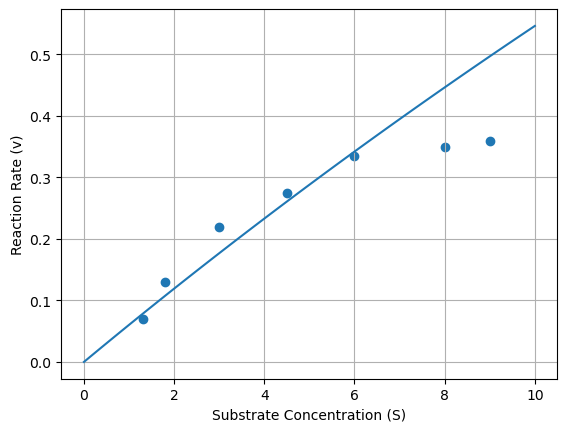

In [54]:
import pylab
plt.scatter(S,v) #Plots the datapoints
Sub = np.linspace(0, 10)  #Various x values (substrate conc.) for plotting model
V = (vm*Sub)/(ks+Sub) #1st order model output given substrate concs., for plotting
plt.plot(Sub,V)
plt.grid()
plt.xlabel("Substrate Concentration (S)")
plt.ylabel("Reaction Rate (v)")

Text(0, 0.5, 'Residuals (error)')

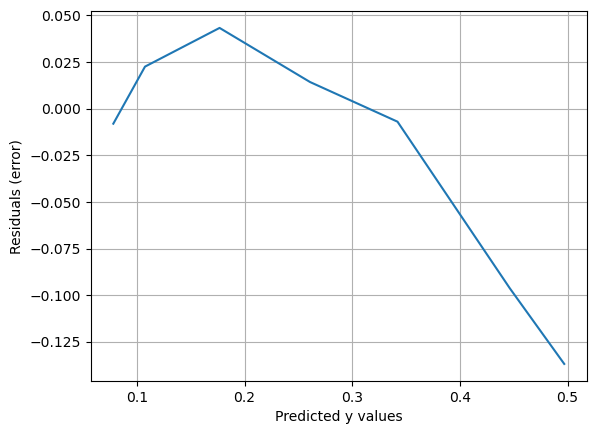

In [55]:
n = len(x)
ypred = np.zeros((n)) #empty variable to fill
e = np.zeros((n))

for i in range (n):
    ypred[i] = (vm*S[i])/(ks+S[i]) #Array of predicted values(use backtransformed model)
    e[i] = v[i] - (vm*S[i])/(ks+S[i]) #Calc difference in measured & predicted
    
pylab.plot(ypred, e)
pylab.grid()
pylab.xlabel("Predicted y values")
pylab.ylabel("Residuals (error)")

## Second Order

In [57]:
x2 = 1.0 / (S ** 2)
y2 = 1.0/v

In [58]:
def strlinregr2(x, y):
    if len(x) != len(y):
        return "x and y must be of the same length"
    n = len(x)
    sumx = np.sum(x)
    xbar = sumx / n
    sumy = np.sum(y)
    ybar = sumy / n
    sumsqx = 0
    sumxy = 0
    for i in range(n):
        sumsqx = sumsqx + x[i]**2
        sumxy = sumxy + x[i]*y[i]
    a1 = (n*sumxy - sumx*sumy) / (n*sumsqx - sumx**2)
    a0 = ybar - a1*xbar

    e = np.zeros((n))
    SST = 0
    SSE = 0
    for i in range(n):
        e[i] = y[i] - (a0 + a1*x[i])
        SST = SST + (y[i] - ybar)**2
        SSE = SSE + e[i]**2
    SSR = SST - SSE
    Rsq = SSR / SST
    SE = np.sqrt(SSE / (n - 2))
    return a0, a1, Rsq, SE

In [59]:
a0, a1, Rsq, SE = strlinregr2(x2, y2)

In [60]:
vm = 1 / a0
ks = np.sqrt(a1 * vm)

In [61]:
print("Intercept = %0.4f" % a0)
print("Slope = %0.4f" % a1)
print("R-squared = %0.4f" % Rsq)
print("Standard Error = %0.4f" % SE)
print("Estimated Maximum Rate (Vm) = %0.4f" % vm)
print("Estimated half-saturation constant (ks) = %0.4f" % ks)

Intercept = 2.4492
Slope = 19.3760
R-squared = 0.9929
Standard Error = 0.3890
Estimated Maximum Rate (Vm) = 0.4083
Estimated half-saturation constant (ks) = 2.8127


Text(0, 0.5, 'Reaction Rate (v)')

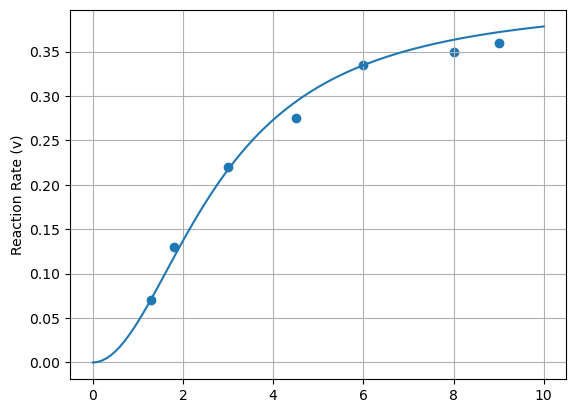

In [62]:
plt.scatter(S, v)
Sub = np.linspace(0, 10, 100)
V = (vm * Sub**2) / (ks**2 + Sub**2)
plt.plot(Sub, V)
plt.grid()
plt.ylabel("Reaction Rate (v)")

In [63]:
n = len(x)
ypred = np.zeros((n))
e = np.zeros((n))
for i in range(n):
    ypred[i] = (vm * S[i]**2) / (ks**2 + S[i]**2)
    e[i] = v[i] - ypred[i]

Text(0, 0.5, 'Residuals (error)')

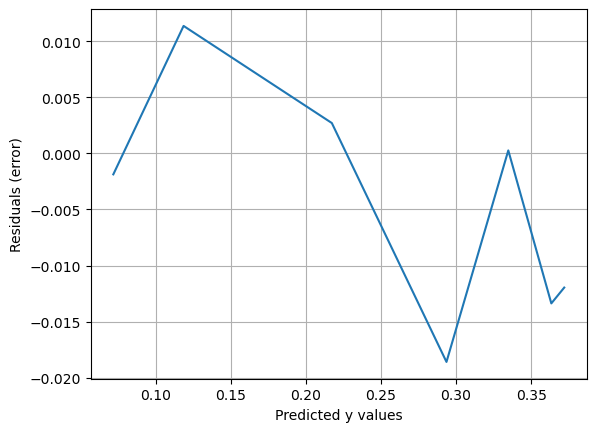

In [64]:
pylab.plot(ypred, e)
pylab.grid()
pylab.xlabel("Predicted y values")
pylab.ylabel("Residuals (error)")

### 1.) How does the first order model perform at approximating the data’s behavior?

The first order model gets the trend of increasing the reaction rate with increasing substrate concentration. It doesn't fit the data exactly. 

At higher substrate concentrations the model underpredicts the reaction rate causing the curve to flatten out too early.

### 2.) How does the second order model perform at approximating the data’s behavior?

The second order model fits the data better than the first order model.

### 3.) What does the plot of residuals versus x for both models tell us about the model adequacy?

First-order residual plot: Shows a distinct pattern with positive residuals at low and high substrate concentrations and negative residuals in the middle range.

Second-order residual plot: Displays more randomly scattered residuals around zero without a clear trend.

### 4.) Which model do you propose as an adequate best-fit model for this data? Why?

The second order model is the best model for this dataset. It provides a higher R² value and produces smaller and more random residuals.